In [15]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from cdt.data import AcyclicGraphGenerator
from causallearn.search.ConstraintBased.PC import pc
from collections import Counter
from pathlib import Path
import os

In [16]:
project_root = Path('./').resolve().parents[2]
base_dir = os.path.join(project_root, 'mastersResearch_Jun_Sept2025', 'causalDiscovery_J')
print(base_dir)

/Users/joshparchure/pyspocClone5Aug/py-spoc/working_analyses/mastersResearch_Jun_Sept2025/causalDiscovery_J


In [17]:
chain_folder = os.path.join(base_dir, 'dataGen', 'chain100data')
loop_folder = os.path.join(base_dir, 'dataGen', 'loop100data')

In [18]:
def run_pc_on_folder(folder_path):
    """Run PC algorithm on all datasets in a folder."""
    
    adjacency_matrices = []
    files = [f for f in os.listdir(folder_path)]
    
    for i, filename in enumerate(files):
        filepath = os.path.join(folder_path, filename)
        
        df = pd.read_csv(filepath)
        data = df.to_numpy()
        cg = pc(data)
        adjacency_matrices.append(cg.G.graph)
        
        if (i + 1) % 10 == 0:
            print(f"  Processed {i + 1}/{len(files)} files")
    
    return adjacency_matrices

In [19]:
def analyze_results(chain_adj_matrices, loop_adj_matrices):
    """Analyze and compare the DAG distributions."""
    
    # Convert adjacency matrices to strings for counting
    chain_dags = [str(adj.tolist()) for adj in chain_adj_matrices]
    loop_dags = [str(adj.tolist()) for adj in loop_adj_matrices]
    
    # Count unique DAGs
    chain_counts = Counter(chain_dags)
    loop_counts = Counter(loop_dags)
    
    print(f"\n=== Results ===")
    print(f"Chain DAG: {len(chain_counts)} unique structures from {len(chain_adj_matrices)} datasets")
    print(f"Loop DAG: {len(loop_counts)} unique structures from {len(loop_adj_matrices)} datasets")
    
    print(f"\nMost common Chain DAG structures:")
    for i, (dag, count) in enumerate(chain_counts.most_common(3)):
        print(f"  #{i+1}: {count} times ({count/len(chain_adj_matrices)*100:.1f}%)")
    
    print(f"\nMost common Loop DAG structures:")
    for i, (dag, count) in enumerate(loop_counts.most_common(3)):
        print(f"  #{i+1}: {count} times ({count/len(loop_adj_matrices)*100:.1f}%)")
    
    return chain_counts, loop_counts

In [20]:
def plot_results(chain_counts, loop_counts):
    """Simple plots of the distributions."""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot frequency of each unique DAG
    chain_freqs = list(chain_counts.values())
    loop_freqs = list(loop_counts.values())
    
    ax1.hist(chain_freqs, bins=10, alpha=0.7, color='blue')
    ax1.set_title('Chain DAG: Frequency Distribution')
    ax1.set_xlabel('How many times each structure appeared')
    ax1.set_ylabel('Number of unique structures')
    
    ax2.hist(loop_freqs, bins=10, alpha=0.7, color='red')
    ax2.set_title('Loop DAG: Frequency Distribution')
    ax2.set_xlabel('How many times each structure appeared')
    ax2.set_ylabel('Number of unique structures')
    
    plt.tight_layout()
    plt.show()

In [21]:
def main():
    """Run the analysis."""
    
    print("Running PC algorithm on chain datasets...")
    chain_adj_matrices = run_pc_on_folder(chain_folder)
    
    print("\nRunning PC algorithm on loop datasets...")
    loop_adj_matrices = run_pc_on_folder(loop_folder)
    
    # Analyze results
    chain_counts, loop_counts = analyze_results(chain_adj_matrices, loop_adj_matrices)
    
    # Plot results
    plot_results(chain_counts, loop_counts)
    
    # Store results if you want them later
    results = {
        'chain_adjacency_matrices': chain_adj_matrices,
        'loop_adjacency_matrices': loop_adj_matrices,
        'chain_counts': chain_counts,
        'loop_counts': loop_counts
    }
    
    return results

Running PC algorithm on chain datasets...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  Processed 100/100 files

=== Results ===
Chain DAG: 100 unique structures from 100 datasets
Loop DAG: 100 unique structures from 100 datasets

Most common Chain DAG structures:
  #1: 1 times (1.0%)
  #2: 1 times (1.0%)
  #3: 1 times (1.0%)

Most common Loop DAG structures:
  #1: 1 times (1.0%)
  #2: 1 times (1.0%)
  #3: 1 times (1.0%)


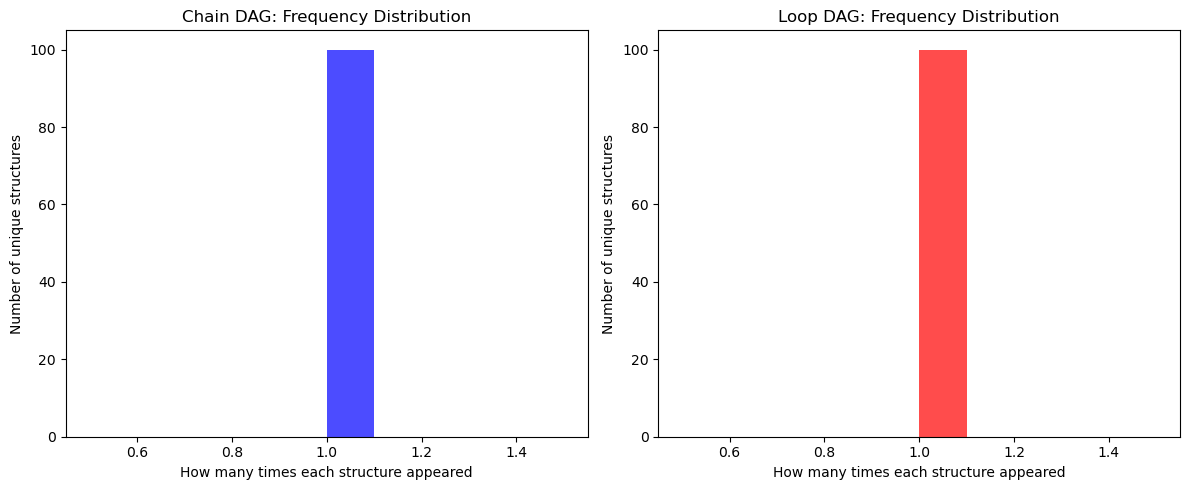

In [22]:
if __name__ == "__main__":
    results = main()

In [35]:
print(results['chain_adjacency_matrices'][4][0])

[0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
